# Chapter 6: 欧氏空间 (Euclidean Space)

在前几章中，我们构建的线性空间是一个“软”的代数世界，我们可以拉伸、剪切向量，但无法衡量它们的长短和夹角。本章我们将引入内积 (Inner Product)，为空间装备“尺子”和“量角器”，从而建立起严格的几何度量体系。我们将探索范数、正交性、柯西-施瓦茨不等式，并动手实现 Gram-Schmidt 正交化以及高维空间中的几何特性验证。

## 6.1 内积的定义与公理验证
在 $\mathbb{R}^n$ 空间中，我们熟悉点积（Dot Product）$\mathbf{x} \cdot \mathbf{y} = \sum x_i y_i$。欧氏空间的定义始于将这一概念公理化。一个合法的内积必须满足四个公理：对称性、线性性、齐次性和正定性。下面的代码定义了一个标准的欧氏内积，并通过随机采样验证这四大公理。

### 内积公理的数值验证

In [1]:
import torch
import numpy as np

# 设置随机种子以保证结果可复现
torch.manual_seed(42)

def euclidean_inner_product(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    计算两个向量的标准欧氏内积: <x, y> = x^T y
    """
    return torch.dot(x, y)

def verify_axioms(dim=5, tol=1e-6):
    print(f"--- 验证 {dim} 维空间内积公理 ---")
    
    # 生成随机向量 alpha, beta, gamma 和标量 k
    alpha = torch.randn(dim)
    beta = torch.randn(dim)
    gamma = torch.randn(dim)
    k = torch.randn(1).item()

    # 1. 对称性 (Symmetry): <alpha, beta> = <beta, alpha>
    lhs = euclidean_inner_product(alpha, beta)
    rhs = euclidean_inner_product(beta, alpha)
    diff = torch.abs(lhs - rhs).item()
    print(f"1. 对称性误差: {diff:.2e} -> {'通过' if diff < tol else '失败'}")

    # 2. 线性性 (Linearity): <alpha + beta, gamma> = <alpha, gamma> + <beta, gamma>
    lhs = euclidean_inner_product(alpha + beta, gamma)
    rhs = euclidean_inner_product(alpha, gamma) + euclidean_inner_product(beta, gamma)
    diff = torch.abs(lhs - rhs).item()
    print(f"2. 线性性误差: {diff:.2e} -> {'通过' if diff < tol else '失败'}")

    # 3. 齐次性 (Homogeneity): <k*alpha, beta> = k*<alpha, beta>
    lhs = euclidean_inner_product(k * alpha, beta)
    rhs = k * euclidean_inner_product(alpha, beta)
    diff = torch.abs(lhs - rhs).item()
    print(f"3. 齐次性误差: {diff:.2e} -> {'通过' if diff < tol else '失败'}")

    # 4. 正定性 (Positive-definiteness): <alpha, alpha> >= 0, 且仅当 alpha=0 时为 0
    self_product = euclidean_inner_product(alpha, alpha)
    is_positive = self_product >= 0
    print(f"4. 正定性检查: <alpha, alpha> = {self_product.item():.4f} >= 0? -> {is_positive}")
    
    # 额外检查零向量
    zero_vec = torch.zeros(dim)
    zero_product = euclidean_inner_product(zero_vec, zero_vec)
    print(f"   零向量检查: <0, 0> = {zero_product.item()} -> {'通过' if zero_product == 0 else '失败'}")

# 运行验证
verify_axioms()

--- 验证 5 维空间内积公理 ---
1. 对称性误差: 0.00e+00 -> 通过
2. 线性性误差: 0.00e+00 -> 通过
3. 齐次性误差: 2.98e-08 -> 通过
4. 正定性检查: <alpha, alpha> = 1.4988 >= 0? -> True
   零向量检查: <0, 0> = 0.0 -> 通过


### 矩阵空间的内积（计算机视觉视角）
书里提到了 $\mathbb{R}^{m \times n}$ 矩阵空间的内积 $(A, B) = \text{tr}(A^T B)$。这听起来很抽象，但实际上它就是卷积神经网络（CNN）中卷积操作的核心（元素对元素相乘再求和）。这个代码块旨在打破“向量必须是一列数”的思维定势，展示矩阵也可以计算夹角。

滤波器与垂直边缘图像的相似度 (Cos): 0.9923
滤波器与水平边缘图像的相似度 (Cos): 0.0000


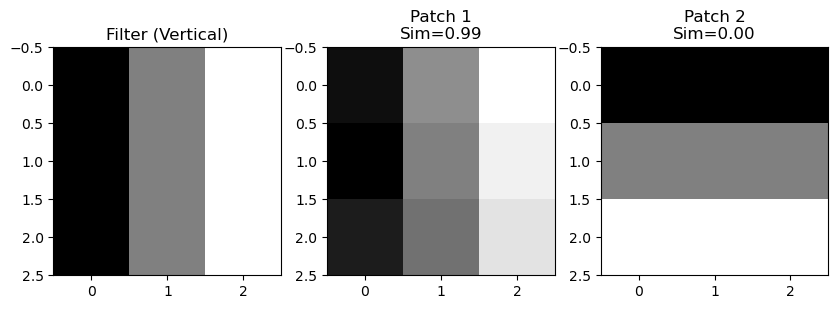

In [ ]:
### 矩阵内积与图像相似度 ###
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def matrix_inner_product(A: torch.Tensor, B: torch.Tensor) -> float:
    """
    计算两个矩阵的内积: <A, B> = tr(A^T B) = sum(A_ij * B_ij)
    """
    # 方法1: 迹的定义 (数学定义)
    trace_val = torch.trace(torch.matmul(A.T, B))
    
    # 方法2: 逐元素相乘求和 (计算高效，且直观)
    # 这在 CNN 中对应卷积核与图像块的运算
    elementwise_sum = torch.sum(A * B)
    
    # 验证两者等价
    assert torch.allclose(trace_val, elementwise_sum, atol=1e-6)
    return elementwise_sum.item()

# --- 模拟视觉任务 ---
# 创建一个简单的 "垂直边缘" 模式 (模拟图像滤波器)
filter_vertical = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0]
])

# 创建两个图像补丁
# Patch 1: 也是垂直边缘 (应该与滤波器相似度高)
image_patch_1 = torch.tensor([
    [-0.8, 0.1, 0.9],
    [-0.9, 0.0, 0.8],
    [-0.7, -0.1, 0.7]
])

# Patch 2: 水平边缘 (应该与滤波器正交/不相似)
image_patch_2 = torch.tensor([
    [-1.0, -1.0, -1.0],
    [ 0.0,  0.0,  0.0],
    [ 1.0,  1.0,  1.0]
])

# 计算内积 (相似度)
score_1 = matrix_inner_product(filter_vertical, image_patch_1)
score_2 = matrix_inner_product(filter_vertical, image_patch_2)

# 归一化为余弦相似度 (为了公平比较)
norm_f = torch.norm(filter_vertical)
cos_sim_1 = score_1 / (norm_f * torch.norm(image_patch_1))
cos_sim_2 = score_2 / (norm_f * torch.norm(image_patch_2))

print(f"滤波器与垂直边缘图像的相似度 (Cos): {cos_sim_1:.4f}")
print(f"滤波器与水平边缘图像的相似度 (Cos): {cos_sim_2:.4f}")

# 可视化
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(filter_vertical, cmap='gray'); ax[0].set_title("Filter (Vertical)")
ax[1].imshow(image_patch_1, cmap='gray'); ax[1].set_title(f"Patch 1\nSim={cos_sim_1:.2f}")
ax[2].imshow(image_patch_2, cmap='gray'); ax[2].set_title(f"Patch 2\nSim={cos_sim_2:.2f}")
plt.show()

## 6.2 柯西-施瓦茨不等式与夹角
欧氏空间几何的基石是 柯西-施瓦茨不等式 (Cauchy-Schwarz Inequality)：$$|\langle \mathbf{x}, \mathbf{y} \rangle| \le \|\mathbf{x}\| \|\mathbf{y}\|$$这个不等式保证了我们可以定义两个向量夹角的余弦值：$$\cos \theta = \frac{\langle \mathbf{x}, \mathbf{y} \rangle}{\|\mathbf{x}\| \|\mathbf{y}\|}$$其值永远在 $[-1, 1]$ 之间。

### 验证柯西-施瓦茨不等式并计算夹角

向量 x: [3. 0.]
向量 y: [1.    1.732]
|<x, y>| = 3.0000
||x|| * ||y|| = 5.9999
柯西-施瓦茨不等式验证: 通过
夹角余弦 cos(theta): 0.5000
夹角 (度): 60.00°


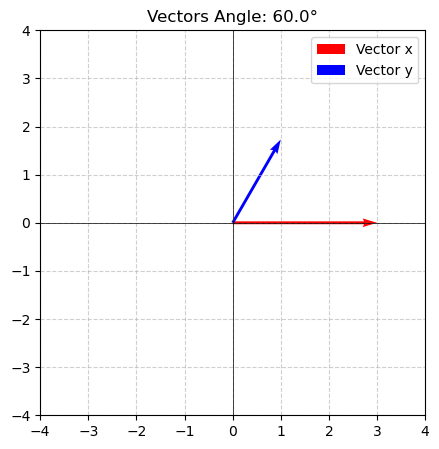

In [2]:
import matplotlib.pyplot as plt

def compute_geometry(x: torch.Tensor, y: torch.Tensor):
    """
    计算范数、内积、验证柯西-施瓦茨不等式并计算夹角
    """
    # 1. 计算范数 (长度)
    norm_x = torch.norm(x) # 等同于 sqrt(<x, x>)
    norm_y = torch.norm(y)
    
    # 2. 计算内积
    inner_prod = euclidean_inner_product(x, y)
    
    # 3. 验证柯西-施瓦茨: |<x,y>| <= ||x|| * ||y||
    product_of_norms = norm_x * norm_y
    abs_inner = torch.abs(inner_prod)
    
    print(f"向量 x: {x.numpy()}")
    print(f"向量 y: {y.numpy()}")
    print(f"|<x, y>| = {abs_inner:.4f}")
    print(f"||x|| * ||y|| = {product_of_norms:.4f}")
    
    assert abs_inner <= product_of_norms + 1e-6, "柯西-施瓦茨不等式被打破！(计算误差除外)"
    print("柯西-施瓦茨不等式验证: 通过")
    
    # 4. 计算夹角 (弧度与角度)
    cos_theta = inner_prod / (product_of_norms + 1e-8) # 加小量防止除零
    # 截断以防浮点误差导致超出 [-1, 1]
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0) 
    
    theta_rad = torch.acos(cos_theta)
    theta_deg = torch.rad2deg(theta_rad)
    
    print(f"夹角余弦 cos(theta): {cos_theta:.4f}")
    print(f"夹角 (度): {theta_deg:.2f}°")
    
    return x, y, theta_deg.item()

# --- 可视化 ---
def plot_vectors(x, y, angle):
    """仅支持 2D 向量的可视化"""
    if x.shape[0] != 2: return
    
    plt.figure(figsize=(5, 5))
    origin = [0, 0]
    
    # 绘制向量
    plt.quiver(*origin, x[0], x[1], color='r', scale=1, scale_units='xy', angles='xy', label='Vector x')
    plt.quiver(*origin, y[0], y[1], color='b', scale=1, scale_units='xy', angles='xy', label='Vector y')
    
    # 设置坐标轴
    limit = max(torch.norm(x).item(), torch.norm(y).item()) + 1
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.title(f"Vectors Angle: {angle:.1f}°")
    plt.show()

# 测试案例
v1 = torch.tensor([3.0, 0.0])
v2 = torch.tensor([1.0, 1.732]) # 接近 (1, sqrt(3))，应为 60 度

x, y, angle = compute_geometry(v1, v2)
plot_vectors(x, y, angle)

### 正交投影与最小二乘（机器学习视角）
书里说“误差向量与子空间正交时，误差最小”。这是线性回归（Linear Regression）的几何本质。这个代码块不直接调用 sklearn 或 torch.nn.Linear，而是利用本章的知识——正规方程 (Normal Equation) $A^T A x = A^T b$ 来手动求解线性回归，完美呼应书中的投影原理。

真实参数: k=2, b=1
最小二乘解: k=1.9067, b=1.3414
误差向量与基底的内积 (应接近0): [1.6868114e-05 1.8119812e-05]


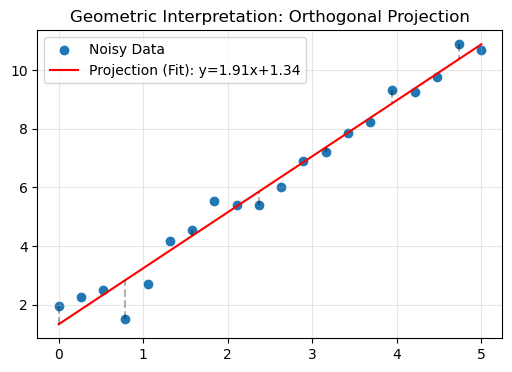

In [ ]:
### 正交投影与最小二乘法 (Linear Regression from Scratch) ###
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

def solve_least_squares(A: torch.Tensor, b: torch.Tensor):
    """
    求解 Ax = b 的最小二乘解。
    几何意义：寻找 b 在 A 的列空间上的正交投影 p = Ax_hat。
    公式：x_hat = (A^T A)^(-1) A^T b
    """
    # 1. 计算 A^T A (Gram Matrix)
    ATA = A.T @ A
    
    # 2. 计算 A^T b
    ATb = A.T @ b
    
    # 3. 求解线性方程组 ATA * x = ATb
    # 注意：实际工程中推荐用 torch.linalg.solve 或 lstsq，这里为了展示公式用 inverse
    # 但前提是 ATA 可逆
    x_hat = torch.linalg.inv(ATA) @ ATb
    return x_hat

# --- 生成带噪声的线性数据 y = 2x + 1 + noise ---
N = 20
x = torch.linspace(0, 5, N)
noise = torch.randn(N) * 0.5
y = 2 * x + 1 + noise

# 构建设计矩阵 A (N x 2)
# 第一列是 x，第二列是 1 (偏置项/截距)
A = torch.stack([x, torch.ones(N)], dim=1)

# 求解最优参数 [slope, intercept]
w_hat = solve_least_squares(A, y)
slope, intercept = w_hat[0].item(), w_hat[1].item()

print(f"真实参数: k=2, b=1")
print(f"最小二乘解: k={slope:.4f}, b={intercept:.4f}")

# 验证几何性质：误差向量 e 是否与 A 的列空间正交？
y_pred = A @ w_hat        # 投影向量 p
error = y - y_pred        # 误差向量 e = b - p

# 检查 e 是否垂直于 A 的每一列
ortho_check = A.T @ error
print(f"误差向量与基底的内积 (应接近0): {ortho_check.detach().numpy()}")

# 可视化
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label='Noisy Data')
plt.plot(x, y_pred, color='red', label=f'Projection (Fit): y={slope:.2f}x+{intercept:.2f}')
# 画出几个点的误差线（投影垂线）
for i in range(0, N, 3):
    plt.plot([x[i], x[i]], [y[i], y_pred[i]], 'k--', alpha=0.3)
plt.title("Geometric Interpretation: Orthogonal Projection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.3 连续函数空间的内积
书中提到了 $C[a, b]$ 空间，内积定义为积分 $(f, g) = \int f(x)g(x) dx$。在计算机中，我们无法直接处理连续无穷维，但可以通过离散化（采样）来模拟。这展示了内积概念的普适性：函数也是向量。

### 函数正交性的离散化模拟

--- 函数空间的正交性模拟 ---
函数 f(x)=1 与 g(x)=x 在 [-1, 1] 上的离散内积: -0.000000
结论: 结果接近 0，说明常数函数与线性函数在对称区间上确实是'垂直'的。


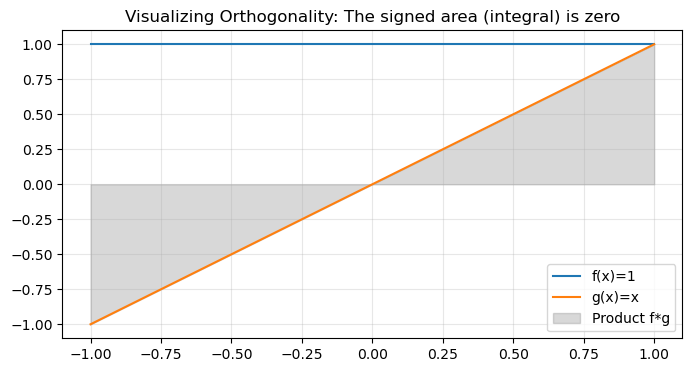

这个图展示了函数 f(x)=1 和 g(x)=x 在区间 [-1, 1] 上的乘积。由于 g(x) 在 x=0 处对称地分布在正负两侧，乘积 f*g 的正负面积相互抵消，导致整体积分（内积）为零。这形象地说明了它们在该区间上的正交性。


In [4]:
def discrete_function_inner_product(f_vals, g_vals, dx):
    """
    通过黎曼和近似计算函数内积: integral(f(x)g(x)dx) approx sum(f*g)*dx
    """
    return torch.sum(f_vals * g_vals) * dx

# 定义区间 [-1, 1]
x_points = torch.linspace(-1, 1, 1000)
dx = x_points[1] - x_points[0]

# 定义两个函数: f(x) = 1 (常数), g(x) = x (线性)
# 理论上它们在 [-1, 1] 上正交
f_vals = torch.ones_like(x_points)
g_vals = x_points

# 计算内积
ip_fg = discrete_function_inner_product(f_vals, g_vals, dx)

print(f"--- 函数空间的正交性模拟 ---")
print(f"函数 f(x)=1 与 g(x)=x 在 [-1, 1] 上的离散内积: {ip_fg.item():.6f}")
print("结论: 结果接近 0，说明常数函数与线性函数在对称区间上确实是'垂直'的。")

# 可视化
plt.figure(figsize=(8, 4))
plt.plot(x_points.numpy(), f_vals.numpy(), label='f(x)=1')
plt.plot(x_points.numpy(), g_vals.numpy(), label='g(x)=x')
plt.fill_between(x_points.numpy(), (f_vals*g_vals).numpy(), alpha=0.3, color='gray', label='Product f*g')
plt.title("Visualizing Orthogonality: The signed area (integral) is zero")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("这个图展示了函数 f(x)=1 和 g(x)=x 在区间 [-1, 1] 上的乘积。由于 g(x) 在 x=0 处对称地分布在正负两侧，乘积 f*g 的正负面积相互抵消，导致整体积分（内积）为零。这形象地说明了它们在该区间上的正交性。")

## 6.4 Gram-Schmidt 正交化与 QR 分解
如何从一组杂乱无章的基向量中，构造出一组完美的标准正交基？答案是 Gram-Schmidt 过程。其核心思想是几何投影：不断减去在已有基方向上的投影分量。

在数值计算中，这一过程对应矩阵的 QR 分解。

### 实现 Gram-Schmidt 算法

In [7]:
import torch

torch.manual_seed(2)

def gram_schmidt(A: torch.Tensor, tol=1e-10) -> torch.Tensor:
    """
    实现修正 Gram-Schmidt (Modified Gram-Schmidt, MGS) 正交化
    相比经典算法，MGS 在数值上更稳定，能减小浮点误差累积。
    """
    n, m = A.shape
    Q = torch.zeros_like(A)
    
    # 在这个算法里，我们并不是对着原始的 A 向量操作，
    # 而是使用一个临时的 V，每次投影后直接更新 V，这样误差更小。
    V = A.clone()
    
    for i in range(m):
        # 1. 归一化第 i 个向量作为基向量 q_i
        norm_v = torch.norm(V[:, i])
        if norm_v < tol:
             raise ValueError("Vectors are linearly dependent (numerically).")
        
        Q[:, i] = V[:, i] / norm_v
        
        # 2. 立即从剩余的所有向量中减去它们在 q_i 上的投影
        # 这是 Modified GS 与 Classical GS 的核心区别
        for j in range(i + 1, m):
            # 计算投影系数 <q_i, v_j>
            proj_coef = (Q[:, i] * V[:, j]).sum() 
            # 更新 v_j：减去投影
            V[:, j] = V[:, j] - proj_coef * Q[:, i]
            
    return Q

# --- 验证环节 ---
# 随机生成一组向量（列）
n, m = 6, 4
A = torch.randn(n, m)

# 1. 运行 Gram-Schmidt
Q = gram_schmidt(A)

# 2. 检验正交归一性：Q^T Q 应该等于 I
G = Q.T @ Q
I = torch.eye(m)
diff = G - I
max_error = diff.abs().max().item()

print("Q^T Q (Result):\n", G.numpy().round(4)) # 只打印4位小数，方便观察
print(f"\nMax off-diagonal error (orthogonality loss): {max_error:.2e}")

# 3. 判定是否正交
# 稍微放宽一点容差，因为即便是 MGS 也有极微小的浮点误差
is_orthogonal = max_error < 1e-5 
print(f"Is Q orthogonal (within tol 1e-5)? {is_orthogonal}")

# 4. 对比 PyTorch 官方 QR 分解 (通常使用 Householder 反射，精度最高)
Q_qr, _ = torch.linalg.qr(A)
print(f"PyTorch QR implementation error: {(Q_qr.T @ Q_qr - I).abs().max().item():.2e}")

Q^T Q (Result):
 [[ 1.  0.  0.  0.]
 [ 0.  1. -0. -0.]
 [ 0. -0.  1. -0.]
 [ 0. -0. -0.  1.]]

Max off-diagonal error (orthogonality loss): 2.23e-07
Is Q orthogonal (within tol 1e-5)? True
PyTorch QR implementation error: 3.58e-07


### 正交变换的“刚性”与行列式（几何视角）
书中区分了旋转（Rotation, det=1）和反射（Reflection, det=-1）。这两个都是正交变换，都保持长度和形状不变，但反射会改变“手性”（像照镜子）。代码通过可视化一个字母 "F"（因为它是不对称的，很容易看出是否被翻转），来直观演示正交矩阵的这两类性质。

原始长度: 2.00, 旋转后长度: 2.00 (应相等)
旋转矩阵行列式: 1.0 (保持手性)
反射矩阵行列式: -1.0 (改变手性)


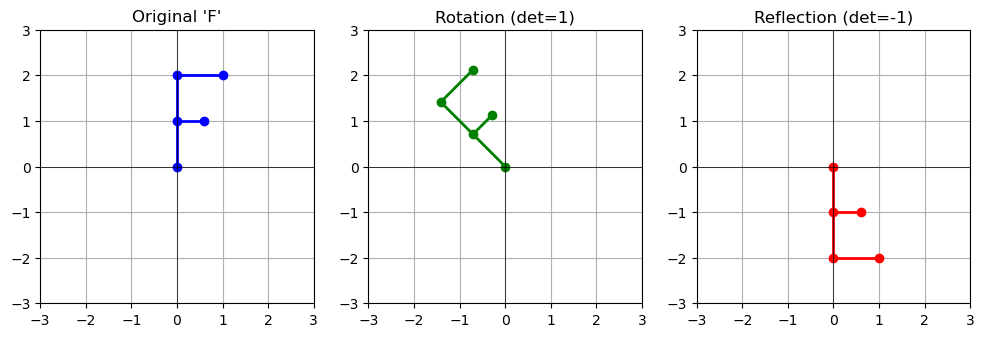

In [10]:
### 旋转 vs 反射 (正交变换的可视化) ###
import torch
import matplotlib.pyplot as plt
import numpy as np

def create_shape_F():
    """创建一个字母 F 的点集用于可视化"""
    # F 的坐标点
    points = torch.tensor([
        [0.0, 0.0], [0.0, 2.0], [1.0, 2.0], # 竖线和上横线
        [0.0, 1.0], [0.6, 1.0]              # 中横线
    ]).T # 变成 2xN 矩阵
    return points

def plot_transform(ax, points, title, color):
    """辅助绘图函数"""
    p = points.numpy()
    ax.plot(p[0, :3], p[1, :3], 'o-', color=color, lw=2) # 画 F 的外框
    ax.plot(p[0, 3:], p[1, 3:], 'o-', color=color, lw=2) # 画 F 的中间
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(True); ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)

# 1. 原始图形
P = create_shape_F()

# 2. 定义旋转矩阵 (Rotation, theta=45度)
theta = torch.tensor(np.pi / 4)
c, s = torch.cos(theta), torch.sin(theta)
Q_rot = torch.tensor([[c, -s], 
                      [s,  c]]) # det = 1

# 3. 定义反射矩阵 (Reflection, 关于 x 轴对称)
# 也是正交矩阵，但 det = -1
Q_ref = torch.tensor([[1.0,  0.0], 
                      [0.0, -1.0]]) 

# 应用变换
P_rot = Q_rot @ P
P_ref = Q_ref @ P

# 验证正交变换的保长性质
len_orig = torch.norm(P[:, 1] - P[:, 0]) # 竖线长度
len_rot  = torch.norm(P_rot[:, 1] - P_rot[:, 0])
print(f"原始长度: {len_orig:.2f}, 旋转后长度: {len_rot:.2f} (应相等)")

# 验证行列式
det_rot = torch.det(Q_rot)
det_ref = torch.det(Q_ref)
print(f"旋转矩阵行列式: {det_rot:.1f} (保持手性)")
print(f"反射矩阵行列式: {det_ref:.1f} (改变手性)")

# 可视化对比 

# [Image of geometric transformations]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plot_transform(axs[0], P, "Original 'F'", 'blue')
plot_transform(axs[1], P_rot, f"Rotation (det={det_rot:.0f})", 'green')
plot_transform(axs[2], P_ref, f"Reflection (det={det_ref:.0f})", 'red')
plt.show()

## 6.5 高维空间的几何直觉：维度的诅咒与祝福
书中提到了一个反直觉的现象：在高维空间中，随机选取的两个向量几乎总是垂直的。

这对深度学习至关重要。这意味着在一个有一百万个参数的神经网络中，随机初始化的权重向量之间天然互不干扰。我们可以通过模拟实验来验证这一数学事实。

### 维度越高，越容易正交

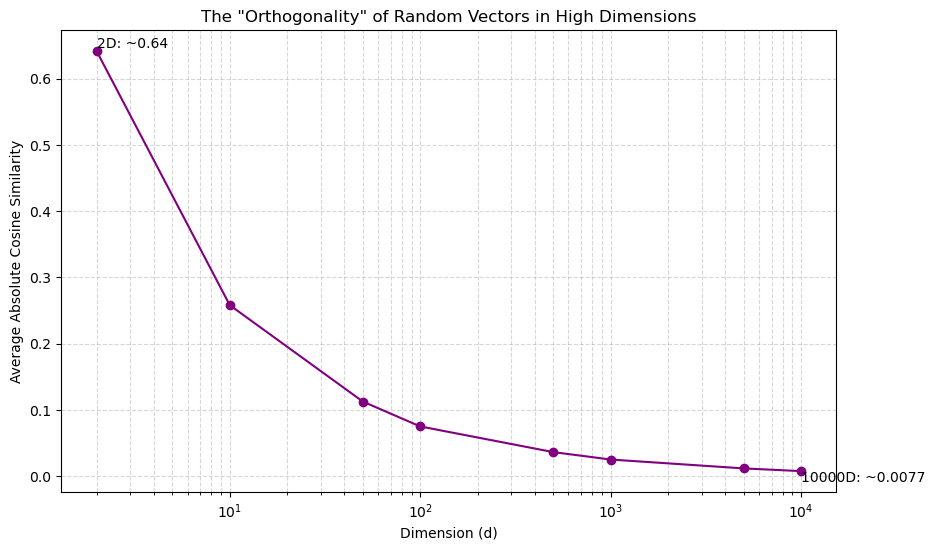

观察结论：
在 2 维空间，随机向量平均夹角余弦较大（容易平行）。
在 10000 维空间，平均余弦相似度仅为 0.0077。
这意味着高维空间中，任意两个随机向量几乎都是正交（垂直）的。


In [6]:
def check_orthogonality_vs_dimension(dims_list, num_trials=1000):
    avg_abs_cosines = []
    
    for d in dims_list:
        # 生成 num_trials 对随机向量
        vecs_a = torch.randn(num_trials, d)
        vecs_b = torch.randn(num_trials, d)
        
        # 计算余弦相似度: <a, b> / (|a|*|b|)
        # 批量点积和范数计算
        dot_prods = (vecs_a * vecs_b).sum(dim=1)
        norms_a = torch.norm(vecs_a, dim=1)
        norms_b = torch.norm(vecs_b, dim=1)
        
        cosines = dot_prods / (norms_a * norms_b)
        
        # 记录余弦值的绝对值平均数 (衡量偏离“垂直”的程度)
        avg_abs_cos = torch.mean(torch.abs(cosines)).item()
        avg_abs_cosines.append(avg_abs_cos)
        
    return avg_abs_cosines

# 定义维度列表：从 2 维到 10000 维
dims = [2, 10, 50, 100, 500, 1000, 5000, 10000]
results = check_orthogonality_vs_dimension(dims)

# 可视化结果
plt.figure(figsize=(10, 6))
plt.plot(dims, results, marker='o', linestyle='-', color='purple')
plt.xscale('log') # 使用对数坐标轴以便更好地展示大跨度
plt.xlabel('Dimension (d)')
plt.ylabel('Average Absolute Cosine Similarity')
plt.title('The "Orthogonality" of Random Vectors in High Dimensions')
plt.grid(True, which="both", ls="--", alpha=0.5)

# 添加文字说明
plt.text(dims[0], results[0], f"2D: ~{results[0]:.2f}", verticalalignment='bottom')
plt.text(dims[-1], results[-1], f"10000D: ~{results[-1]:.4f}", verticalalignment='top')

plt.show()

print("观察结论：")
print("在 2 维空间，随机向量平均夹角余弦较大（容易平行）。")
print(f"在 {dims[-1]} 维空间，平均余弦相似度仅为 {results[-1]:.4f}。")
print("这意味着高维空间中，任意两个随机向量几乎都是正交（垂直）的。")